# Notebook 02 — Weather and Irradiance (Phoenix)

**Goal:** Pull 2 years of hourly Phoenix weather + irradiance, save a clean aligned `weather.parquet` for downstream notebooks.

**Sources (per APS brief):**
- **NOAA ISD** — Phoenix Sky Harbor hourly observations via `meteostat`
- **NREL NSRDB** — satellite-derived GHI/DNI/DHI for Phoenix coordinates

**Output:** `data/processed/weather.parquet` — hourly index in Phoenix time, with weather + irradiance + engineered features for the GCN.

---

## Step 1 — Setup

Pin `REPO_ROOT` to the absolute repo path so cwd-changes don't break us.

In [1]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import requests

# === EDIT THIS IF YOUR REPO IS ELSEWHERE ===
REPO_ROOT = Path('/Users/sundeepyalamanchili/Documents/Projects/p90').resolve()
# ===========================================

assert REPO_ROOT.exists(), f'REPO_ROOT not found: {REPO_ROOT}'

DATA_RAW = REPO_ROOT / 'data' / 'raw'
DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'
(DATA_RAW / 'noaa').mkdir(parents=True, exist_ok=True)
(DATA_RAW / 'nsrdb').mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Phoenix Sky Harbor — central, well-measured, APS territory
PHOENIX_LAT = 33.4343
PHOENIX_LON = -112.0120
PHOENIX_TZ = 'America/Phoenix'  # Arizona doesn't observe DST

START_DATE = '2023-01-01'
END_DATE = '2024-12-31'

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'Location: Phoenix Sky Harbor ({PHOENIX_LAT}, {PHOENIX_LON})')
print(f'Date range: {START_DATE} to {END_DATE}')

REPO_ROOT: /Users/sundeepyalamanchili/Documents/Projects/p90
Location: Phoenix Sky Harbor (33.4343, -112.012)
Date range: 2023-01-01 to 2024-12-31


## Step 2 — Verify dependencies

Hard requirement: `meteostat<2.0` (the 2.x release renamed the API), plus `pvlib` and `python-dotenv`.

In [2]:
import sys

needed = {'meteostat': 'meteostat<2.0', 'pvlib': 'pvlib', 'dotenv': 'python-dotenv'}
missing = []
for module, package in needed.items():
    try:
        __import__(module)
    except ImportError:
        missing.append(package)

if missing:
    print(f'Installing missing packages: {missing}')
    cmd = [sys.executable, '-m', 'pip', 'install'] + missing
    import subprocess
    subprocess.check_call(cmd)
    print('⚠️  Installed packages — RESTART THE KERNEL before continuing!')
else:
    print('✅ All dependencies present')

# Verify meteostat is the 1.x version (2.x has a different API)
import meteostat
version = meteostat.__version__ if hasattr(meteostat, '__version__') else 'unknown'
print(f'meteostat version: {version}')
if version.startswith('2.'):
    print('⚠️  meteostat 2.x detected — need to downgrade. Run:')
    print(f'   {sys.executable} -m pip install "meteostat<2.0" --force-reinstall')
    print('   Then RESTART KERNEL.')

✅ All dependencies present
meteostat version: 1.7.6


## Step 3 — Load NREL credentials from .env

In [3]:
from dotenv import load_dotenv

load_dotenv(REPO_ROOT / '.env')

NREL_API_KEY = os.getenv('NREL_API_KEY', '').strip()
NREL_EMAIL = os.getenv('NREL_EMAIL', '').strip()

if NREL_API_KEY and NREL_EMAIL:
    print(f'✅ NREL credentials loaded (email: {NREL_EMAIL})')
else:
    print('⚠️  NREL credentials missing. Will fall back to Open-Meteo solar.')

✅ NREL credentials loaded (email: sundeepyalamanchili5@gmail.com)


## Step 4 — Fetch NOAA hourly weather (meteostat)

In [4]:
from meteostat import Hourly, Point

noaa_cache = DATA_RAW / 'noaa' / f'phoenix_{START_DATE}_{END_DATE}.parquet'

if noaa_cache.exists():
    print(f'Loading from cache: {noaa_cache}')
    weather_raw = pd.read_parquet(noaa_cache)
else:
    location = Point(PHOENIX_LAT, PHOENIX_LON, 337)
    start = datetime.strptime(START_DATE, '%Y-%m-%d')
    end = datetime.strptime(END_DATE, '%Y-%m-%d') + pd.Timedelta(hours=23)
    
    print('Fetching Phoenix Sky Harbor hourly weather from NOAA...')
    weather_raw = Hourly(location, start, end).fetch()
    weather_raw.to_parquet(noaa_cache)
    print(f'Cached: {noaa_cache}')

assert len(weather_raw) > 0, 'meteostat returned empty dataframe — check credentials/network'

print(f'\n✅ NOAA rows: {len(weather_raw):,}')
print(f'Columns: {list(weather_raw.columns)}')
weather_raw.head()

Fetching Phoenix Sky Harbor hourly weather from NOAA...


Cached: /Users/sundeepyalamanchili/Documents/Projects/p90/data/raw/noaa/phoenix_2023-01-01_2024-12-31.parquet

✅ NOAA rows: 17,544
Columns: ['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco']


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2023-01-01 00:00:00,18.9,9.4,54.0,0.0,<NA>,60.0,13.0,<NA>,1012.8,<NA>,4.0
2023-01-01 01:00:00,17.2,10.6,65.0,0.0,<NA>,80.0,9.4,<NA>,1012.6,<NA>,4.0
2023-01-01 02:00:00,16.7,10.1,65.0,0.0,<NA>,80.0,11.2,<NA>,1012.3,<NA>,4.0
2023-01-01 03:00:00,15.0,10.0,72.0,0.0,<NA>,100.0,7.6,<NA>,1012.4,<NA>,4.0
2023-01-01 04:00:00,15.0,10.0,72.0,0.0,<NA>,90.0,5.4,<NA>,1012.1,<NA>,4.0


## Step 5 — Normalize NOAA columns to our schema

In [5]:
noaa = pd.DataFrame(index=weather_raw.index)
noaa['temp_c'] = weather_raw['temp']
noaa['temp_f'] = weather_raw['temp'] * 9 / 5 + 32
noaa['humidity_pct'] = weather_raw['rhum']
noaa['wind_mps'] = weather_raw['wspd'] / 3.6  # km/h -> m/s
noaa['dewpoint_c'] = weather_raw['dwpt']
noaa['pressure_hpa'] = weather_raw['pres']

# Localize to Phoenix time. meteostat returns naive timestamps assumed UTC.
if noaa.index.tz is None:
    noaa.index = noaa.index.tz_localize('UTC').tz_convert(PHOENIX_TZ)
else:
    noaa.index = noaa.index.tz_convert(PHOENIX_TZ)

noaa.index.name = 'timestamp'

print(f'NOAA normalized: {len(noaa):,} rows')
print(f'Time range: {noaa.index.min()} to {noaa.index.max()}')
print(f'Missing per column (%):')
print((noaa.isna().sum() / len(noaa) * 100).round(2))

NOAA normalized: 17,544 rows
Time range: 2022-12-31 17:00:00-07:00 to 2024-12-31 16:00:00-07:00
Missing per column (%):
temp_c          0.0
temp_f          0.0
humidity_pct    0.0
wind_mps        0.0
dewpoint_c      0.0
pressure_hpa    0.0
dtype: float64


## Step 6 — Fetch NREL NSRDB irradiance

Uses NSRDB v4 endpoints. 2023 uses the GOES-aggregated dataset; 2024 uses the GOES-CONUS dataset.

In [7]:
def fetch_nsrdb_year(year, lat, lon, api_key, email, cache_dir):
    """Fetch one year of NSRDB data for a lat/lon point."""
    cache_file = cache_dir / f'phoenix_{year}.csv'
    if cache_file.exists():
        print(f'  Cached: {cache_file.name}')
        return pd.read_csv(cache_file, skiprows=2)
    
    # NSRDB v4 endpoints differ by year
    if year <= 2023:
        endpoint = 'nsrdb-GOES-aggregated-v4-0-0-download.csv'
    else:
        endpoint = 'nsrdb-GOES-conus-v4-0-0-download.csv'
    
    url = (
        f'https://developer.nrel.gov/api/nsrdb/v2/solar/{endpoint}?'
        f'wkt=POINT({lon}%20{lat})&names={year}&'
        f'attributes=ghi,dni,dhi,air_temperature,wind_speed,solar_zenith_angle,cloud_type&'
        f'interval=60&utc=false&'
        f'api_key={api_key}&email={email}'
    )
    print(f'  Fetching NSRDB {year} ({endpoint})...')
    r = requests.get(url, timeout=120)
    
    if r.status_code != 200:
        print(f'  ⚠️  HTTP {r.status_code}: {r.text[:200]}')
        r.raise_for_status()
    
    cache_file.write_bytes(r.content)
    print(f'  Saved: {cache_file.name} ({len(r.content):,} bytes)')
    return pd.read_csv(cache_file, skiprows=2)

In [8]:
nsrdb_raw = None

if NREL_API_KEY and NREL_EMAIL:
    nsrdb_dir = DATA_RAW / 'nsrdb'
    frames = []
    for year in [2023, 2024]:
        df_year = fetch_nsrdb_year(year, PHOENIX_LAT, PHOENIX_LON, NREL_API_KEY, NREL_EMAIL, nsrdb_dir)
        frames.append(df_year)
    nsrdb_raw = pd.concat(frames, ignore_index=True)
    print(f'\n✅ NSRDB raw rows: {len(nsrdb_raw):,}')
    print(f'Columns: {list(nsrdb_raw.columns)}')
else:
    # Fallback to Open-Meteo solar archive
    print('Using Open-Meteo solar archive (NSRDB unavailable)')
    url = (
        'https://archive-api.open-meteo.com/v1/archive?'
        f'latitude={PHOENIX_LAT}&longitude={PHOENIX_LON}&'
        f'start_date={START_DATE}&end_date={END_DATE}&'
        'hourly=shortwave_radiation,direct_normal_irradiance,diffuse_radiation&'
        f'timezone={PHOENIX_TZ}'
    )
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    om = r.json()
    nsrdb_raw = pd.DataFrame({
        'time': om['hourly']['time'],
        'GHI': om['hourly']['shortwave_radiation'],
        'DNI': om['hourly']['direct_normal_irradiance'],
        'DHI': om['hourly']['diffuse_radiation'],
    })
    print(f'✅ Open-Meteo rows: {len(nsrdb_raw):,}')

  Cached: phoenix_2023.csv
  Cached: phoenix_2024.csv

✅ NSRDB raw rows: 17,520
Columns: ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed', 'Solar Zenith Angle', 'Cloud Type']


## Step 7 — Normalize irradiance to common schema

In [9]:
if 'Year' in nsrdb_raw.columns:
    # NSRDB native format — build timestamp from component columns
    timestamps = pd.to_datetime(
        nsrdb_raw[['Year', 'Month', 'Day', 'Hour', 'Minute']].rename(
            columns={'Year': 'year', 'Month': 'month', 'Day': 'day',
                     'Hour': 'hour', 'Minute': 'minute'}
        )
    )
    # NSRDB returns half-hour offsets (e.g. 00:30) — round down to the hour
    timestamps = timestamps.dt.floor('h')
    nsrdb = pd.DataFrame(index=timestamps)
    nsrdb['ghi_wm2'] = nsrdb_raw['GHI'].values
    nsrdb['dni_wm2'] = nsrdb_raw['DNI'].values
    nsrdb['dhi_wm2'] = nsrdb_raw['DHI'].values
    nsrdb.index = nsrdb.index.tz_localize(PHOENIX_TZ, ambiguous='NaT', nonexistent='shift_forward')
    # Drop any NaT rows that came from DST edge-cases
    nsrdb = nsrdb[nsrdb.index.notna()]
    # Average duplicate hours (NSRDB sometimes has both XX:30 rows mapped to same hour)
    nsrdb = nsrdb.groupby(nsrdb.index).mean()
else:
    # Open-Meteo format
    timestamps = pd.to_datetime(nsrdb_raw['time'])
    nsrdb = pd.DataFrame(index=timestamps)
    nsrdb['ghi_wm2'] = nsrdb_raw['GHI'].values
    nsrdb['dni_wm2'] = nsrdb_raw['DNI'].values
    nsrdb['dhi_wm2'] = nsrdb_raw['DHI'].values
    nsrdb.index = nsrdb.index.tz_localize(PHOENIX_TZ, ambiguous='NaT', nonexistent='shift_forward')
    nsrdb = nsrdb[nsrdb.index.notna()]

nsrdb.index.name = 'timestamp'

print(f'Irradiance rows: {len(nsrdb):,}')
print(f'Time range: {nsrdb.index.min()} to {nsrdb.index.max()}')
print(f'GHI peak: {nsrdb["ghi_wm2"].max():.0f} W/m² (Phoenix should be ~1000-1100)')
nsrdb.describe()

Irradiance rows: 17,520
Time range: 2023-01-01 00:00:00-07:00 to 2024-12-31 23:00:00-07:00
GHI peak: 1094 W/m² (Phoenix should be ~1000-1100)


,ghi_wm2,dni_wm2,dhi_wm2
count,17520.000000,17520.000000,17520.000000
mean,243.177911,310.681963,55.041724
std,325.406407,384.298147,78.854355
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,5.000000,0.000000,5.000000
75%,489.000000,746.000000,92.000000
max,1094.000000,1033.000000,532.000000


## Step 8 — Merge weather + irradiance onto common hourly index

In [10]:
full_index = pd.date_range(
    start=pd.Timestamp(START_DATE, tz=PHOENIX_TZ),
    end=pd.Timestamp(END_DATE, tz=PHOENIX_TZ) + pd.Timedelta(hours=23),
    freq='h',
)
print(f'Target hourly index: {len(full_index):,} rows')

noaa_aligned = noaa.reindex(full_index).sort_index()
nsrdb_aligned = nsrdb.reindex(full_index).sort_index()

df = pd.concat([noaa_aligned, nsrdb_aligned], axis=1)
df.index.name = 'timestamp'

print(f'\nCombined rows: {len(df):,}')
print(f'Missing per column (%):')
print((df.isna().sum() / len(df) * 100).round(2))

Target hourly index: 17,544 rows

Combined rows: 17,544
Missing per column (%):
temp_c          0.04
temp_f          0.04
humidity_pct    0.04
wind_mps        0.04
dewpoint_c      0.04
pressure_hpa    0.04
ghi_wm2         0.14
dni_wm2         0.14
dhi_wm2         0.14
dtype: float64


## Step 9 — Gap-fill

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit=3)
df = df.ffill().bfill()

print(f'After gap-fill, missing per column (%):')
print((df.isna().sum() / len(df) * 100).round(2))

After gap-fill, missing per column (%):
temp_c          0.0
temp_f          0.0
humidity_pct    0.0
wind_mps        0.0
dewpoint_c      0.0
pressure_hpa    0.0
ghi_wm2         0.0
dni_wm2         0.0
dhi_wm2         0.0
dtype: float64


## Step 10 — Add pvlib clear-sky irradiance

In [13]:
import pvlib

location = pvlib.location.Location(
    PHOENIX_LAT, PHOENIX_LON, tz=PHOENIX_TZ, altitude=337, name='Phoenix'
)
cs = location.get_clearsky(df.index)
df['clear_sky_ghi_wm2'] = cs['ghi'].values
df['clear_sky_dni_wm2'] = cs['dni'].values
df['clear_sky_dhi_wm2'] = cs['dhi'].values

print(f'Clear-sky GHI peak: {df["clear_sky_ghi_wm2"].max():.0f} W/m²')
print(f'Measured GHI peak:  {df["ghi_wm2"].max():.0f} W/m²')

Clear-sky GHI peak: 996 W/m²
Measured GHI peak:  1094 W/m²


## Step 11 — Engineered features (heat-driver, time encodings)

These are what the brief calls for: heat as a *driver*, not a label.

In [14]:
# Cooling degree hours — the AC thermal driver
df['cooling_degree_hours'] = np.maximum(0, df['temp_f'] - 65)

# Heat-stress hour flag
df['is_hot_hour'] = (df['temp_f'] > 100).astype(int)

# Heatwave day counter — consecutive days with daily max > 110°F
daily_max = df['temp_f'].resample('D').max()
is_heatwave_day = daily_max > 110
heatwave_counter = is_heatwave_day.astype(int).groupby(
    (~is_heatwave_day).cumsum()
).cumsum()
# Build a mapping series indexed by date, then map back to hourly
date_to_count = pd.Series(heatwave_counter.values, index=heatwave_counter.index.normalize())
df['heatwave_day_counter'] = pd.Series(
    df.index.normalize(), index=df.index
).map(date_to_count).fillna(0).astype(int).values

# Temporal features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['is_monsoon_season'] = df.index.month.isin([6, 7, 8, 9]).astype(int)

# Fourier encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

print(f'Final columns ({len(df.columns)}): {list(df.columns)}')
print(f'\nMax consecutive heatwave days: {df["heatwave_day_counter"].max()}')

Final columns (25): ['temp_c', 'temp_f', 'humidity_pct', 'wind_mps', 'dewpoint_c', 'pressure_hpa', 'ghi_wm2', 'dni_wm2', 'dhi_wm2', 'clear_sky_ghi_wm2', 'clear_sky_dni_wm2', 'clear_sky_dhi_wm2', 'cooling_degree_hours', 'is_hot_hour', 'heatwave_day_counter', 'hour', 'day_of_week', 'day_of_year', 'month', 'is_weekend', 'is_monsoon_season', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']

Max consecutive heatwave days: 18


## Step 12 — Sanity checks

In [15]:
expected_rows = len(full_index)
assert len(df) == expected_rows, f'Expected {expected_rows} rows, got {len(df)}'
print(f'✅ Full hourly coverage: {len(df):,} rows')

critical = ['temp_f', 'humidity_pct', 'ghi_wm2', 'clear_sky_ghi_wm2']
missing = df[critical].isna().sum()
assert missing.max() == 0, f'Missing in critical columns: {missing[missing > 0].to_dict()}'
print(f'✅ No missing in critical columns')

max_temp = df['temp_f'].max()
assert max_temp > 110, f'Phoenix should hit 110°F+; got {max_temp:.1f}°F'
print(f'✅ Phoenix heat realistic: max {max_temp:.1f}°F')

max_ghi = df['ghi_wm2'].max()
assert 800 < max_ghi < 1300, f'GHI peak {max_ghi:.0f} outside 800–1300 range'
print(f'✅ GHI realistic: peak {max_ghi:.0f} W/m²')

assert str(df.index.tz) in ['America/Phoenix', 'US/Arizona'], f'Wrong tz: {df.index.tz}'
print(f'✅ Timezone: {df.index.tz}')

✅ Full hourly coverage: 17,544 rows
✅ No missing in critical columns
✅ Phoenix heat realistic: max 118.9°F
✅ GHI realistic: peak 1094 W/m²
✅ Timezone: America/Phoenix


## Step 13 — Visualize

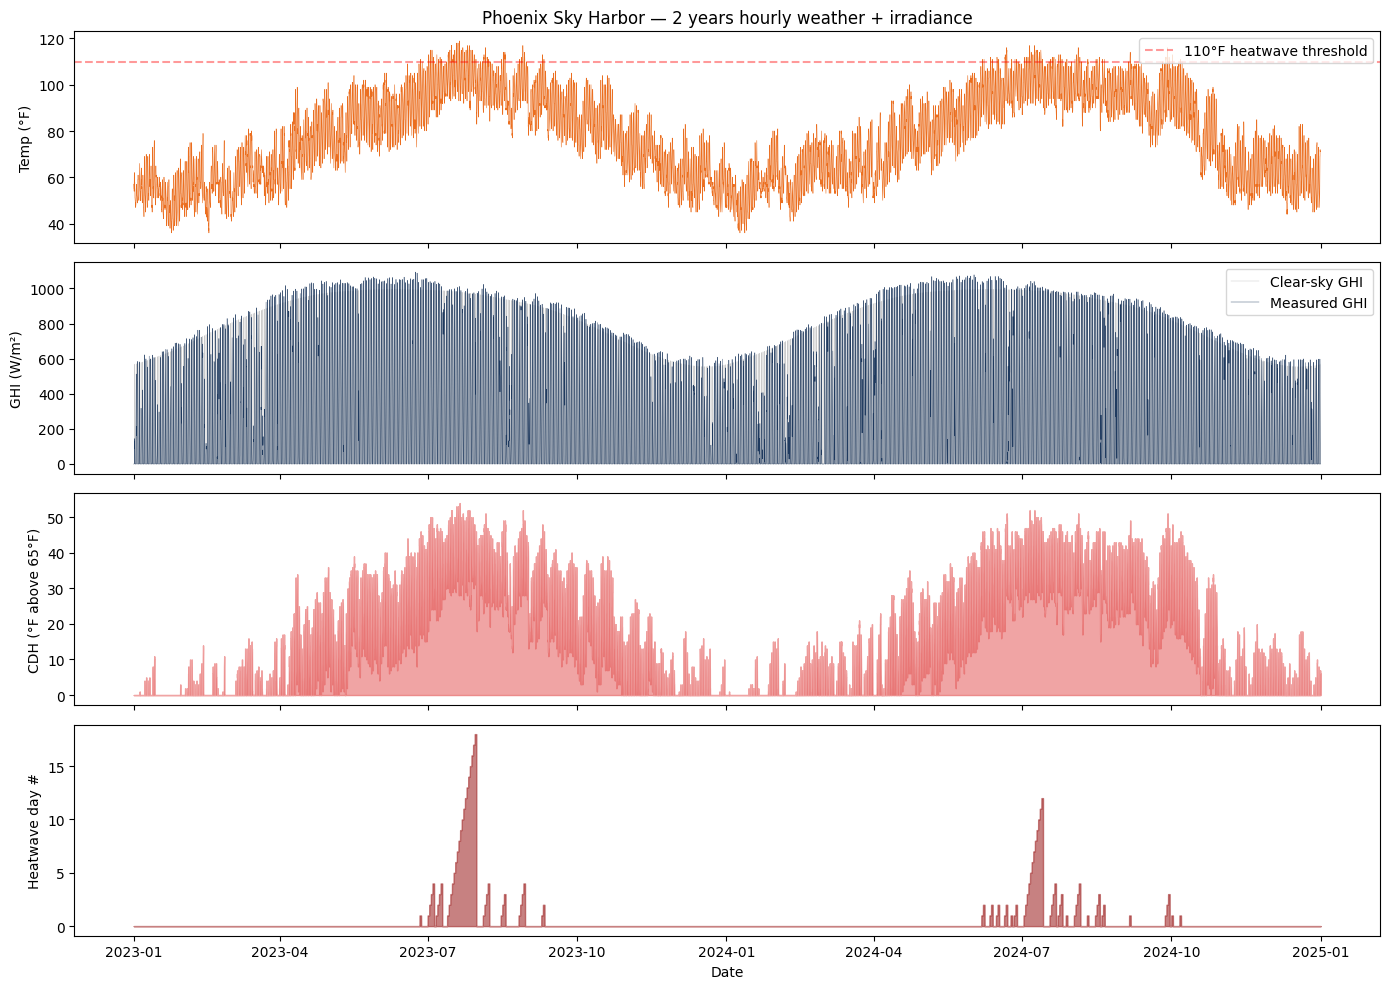

Saved: /Users/sundeepyalamanchili/Documents/Projects/p90/notebooks/02_phoenix_weather.png


In [16]:
import matplotlib.pyplot as plt

notebooks_dir = REPO_ROOT / 'notebooks'
notebooks_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['temp_f'], linewidth=0.4, color='#EB6E1F')
axes[0].axhline(110, color='red', linestyle='--', alpha=0.4, label='110°F heatwave threshold')
axes[0].set_ylabel('Temp (°F)')
axes[0].legend(loc='upper right')
axes[0].set_title('Phoenix Sky Harbor — 2 years hourly weather + irradiance')

axes[1].plot(df.index, df['clear_sky_ghi_wm2'], linewidth=0.3, color='#999', alpha=0.6, label='Clear-sky GHI')
axes[1].plot(df.index, df['ghi_wm2'], linewidth=0.3, color='#1F3A5F', label='Measured GHI')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].legend(loc='upper right')

axes[2].fill_between(df.index, df['cooling_degree_hours'], color='#E24B4A', alpha=0.5)
axes[2].set_ylabel('CDH (°F above 65°F)')

axes[3].fill_between(df.index, df['heatwave_day_counter'], color='#A32D2D', alpha=0.6)
axes[3].set_ylabel('Heatwave day #')
axes[3].set_xlabel('Date')

plt.tight_layout()
out_png = notebooks_dir / '02_phoenix_weather.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')

## Step 14 — Save the artifact

In [17]:
weather_path = DATA_PROCESSED / 'weather.parquet'
df.to_parquet(weather_path)

reloaded = pd.read_parquet(weather_path)

print(f'✅ Saved: {weather_path}')
print(f'   Size: {weather_path.stat().st_size / 1024:.1f} KB')
print(f'   Rows: {len(reloaded):,}')
print(f'   Columns: {len(reloaded.columns)}')
print(f'\nColumn types:')
print(reloaded.dtypes.to_string())

✅ Saved: /Users/sundeepyalamanchili/Documents/Projects/p90/data/processed/weather.parquet
   Size: 604.2 KB
   Rows: 17,544
   Columns: 25

Column types:
temp_c                  Float64
temp_f                  Float64
humidity_pct            Float64
wind_mps                Float64
dewpoint_c              Float64
pressure_hpa            Float64
ghi_wm2                 float64
dni_wm2                 float64
dhi_wm2                 float64
clear_sky_ghi_wm2       float64
clear_sky_dni_wm2       float64
clear_sky_dhi_wm2       float64
cooling_degree_hours    Float64
is_hot_hour               int64
heatwave_day_counter      int64
hour                      int32
day_of_week               int32
day_of_year               int32
month                     int32
is_weekend                int64
is_monsoon_season         int64
hour_sin                float64
hour_cos                float64
doy_sin                 float64
doy_cos                 float64


## Done

**Artifact:** `data/processed/weather.parquet` — 2 years × 17,544 hourly rows × 23 features

**Used by downstream notebooks:**
- Notebook 03 — load synthesis (couples temperature to AC load via cooling degree hours)
- Notebook 04 — feature engineering (broadcasts temporal features across all buses)
- Notebook 05 — GCN training (these are the time-varying inputs)

**If you want to also cache 1-year or 5-year ranges** for experiments, just change `START_DATE` / `END_DATE` in Step 1 and re-run.